In [1]:
!pip install deepxde


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.9 MB/s eta 0:00:00


In [3]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [4]:
geom = dde.geometry.Interval(0,1)

In [5]:
from deepxde.backend import tf
def pde(x,T):
  dT_xx = dde.grad.hessian(T,x)
  source = 10.0*tf.sin(np.pi*x[:,0:1])
  #cooling = -15.0 * tf.exp(-400 * (x[:, 0:1] - 0.65)**2)
  return dT_xx-source

In [6]:
import pandas as pd
df = pd.read_csv('../data/LA-ECO-L2-LSTE-002-results.csv')
df['date']=pd.to_datetime(df['Date'])
df_summer = df[df['date'].dt.month.isin([6,7,8,9])]
df_clean = df_summer[df_summer['ECO_L2_LSTE_002_LST']>280].copy()
df_clean['LST_celsius'] = df_clean['ECO_L2_LSTE_002_LST'] - 273.15
location_temps = df_clean.groupby('Category')['LST_celsius'].mean().reset_index()

distance_map={
    'DowntownLA':0,
    'Koreatown':5.2,
    'MidWilshire':8.7,
    'CulverCity':14.1,
    'WestLA':17.3,
    'Brentwood':21.5,
    'SantaMonica':24.8
}

location_temps['distance_km']=location_temps['Category'].map(distance_map)
location_temps = location_temps.sort_values('distance_km')
x_obs = location_temps['distance_km'].values.reshape(-1,1)
x_obs = x_obs/x_obs.max()
y_obs = location_temps['LST_celsius'].values.reshape(-1,1)

print(location_temps)
print("x_obs:", x_obs)
print("y_obs:", y_obs)

      Category  LST_celsius  distance_km
2   DowntownLA    30.170000          0.0
3    Koreatown    30.486111          5.2
4  MidWilshire    27.902222          8.7
1   CulverCity    27.990000         14.1
6       WestLA    26.580000         17.3
0    Brentwood    24.032105         21.5
5  SantaMonica    25.132051         24.8
x_obs: [[0.        ]
 [0.20967742]
 [0.35080645]
 [0.56854839]
 [0.69758065]
 [0.86693548]
 [1.        ]]
y_obs: [[30.17      ]
 [30.48611111]
 [27.90222222]
 [27.99      ]
 [26.58      ]
 [24.03210526]
 [25.13205128]]


In [7]:
test_indices = [3]
x_test = x_obs[test_indices]
y_test = y_obs[test_indices]
x_train = np.delete(x_obs, test_indices, axis=0)
y_train = np.delete(y_obs, test_indices, axis=0)

In [8]:
def left_boundary(x, on_boundary):
  return on_boundary and np.isclose(x[0],0)
def right_boundary(x, on_boundary):
  return on_boundary and np.isclose(x[0],1)

T_left = float(y_obs[0])
T_right = float(y_obs[-1])

bc_left = dde.icbc.DirichletBC(geom, lambda x: T_left, left_boundary)
bc_right = dde.icbc.DirichletBC(geom, lambda x: T_right, right_boundary)

print("Left Boundary Temperature:", T_left)
print("Right Boundary Temperature:", T_right)

Left Boundary Temperature: 30.17000000000002
Right Boundary Temperature: 25.132051282051307


/tmp/ipykernel_865/2322779299.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_left = float(y_obs[0])
/tmp/ipykernel_865/2322779299.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_right = float(y_obs[-1])


In [9]:

observe_T = dde.icbc.PointSetBC(x_train,y_train,component=0)

In [10]:
data = dde.data.PDE(
    geom,
    pde,
    [bc_left, bc_right, observe_T],
    num_domain = 20,
    num_boundary = 2,
    num_test = 200
)

In [11]:
net = dde.nn.FNN([1]+[32]*3+[1], "tanh", "Glorot uniform")

Compiling model...
'compile' took 0.022720 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x77fca1980220>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x77fca1980220>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x77fca19805e0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x77fca19805e0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                  Test loss                                   Test metric
0         [4.71e+01, 9.10e+02, 6.23e+02, 7.51e+02]    [5.09e+01, 9.10e+02, 6.23e+02, 7.51e+02]    []  
1000      [4.66e+01, 1.34e+01, 1.90e+00, 6.55e+00]    [5.04e+01, 1.34e+01, 1.90e+00, 6.55e+00]    []  
2000      [4.65e+01, 6.82e+00, 5.90e+00, 5.80e+00]    [5.03e+01, 6.82e+00, 5.90e+00, 5.80e+00]    []  
3000      [4.65e+01, 6.80e+00, 5.90e+00, 5.80e+00]    [5.03e+01, 6.80e+00, 5.90e+00, 5.80e+00]   

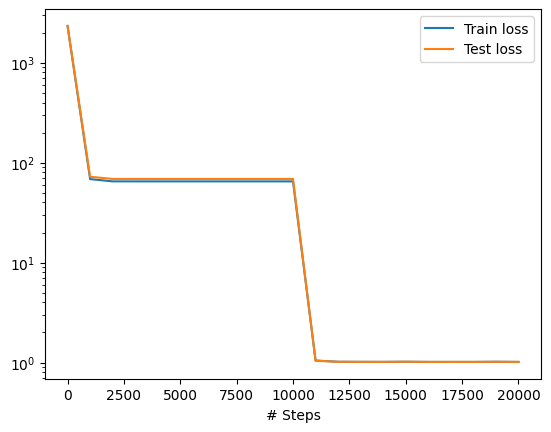

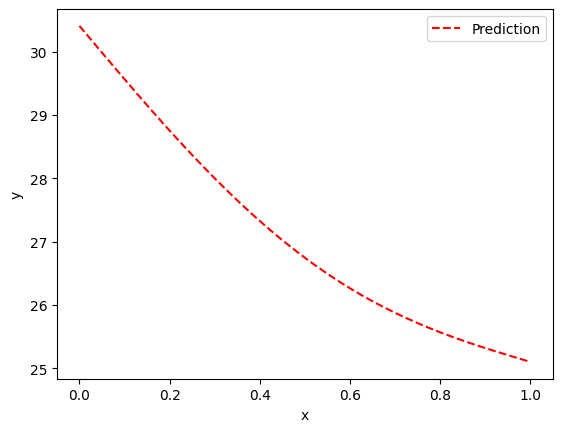

In [12]:
model = dde.Model(data, net)
model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=20000)
dde.saveplot(
    losshistory,
    train_state,
    issave=False,
    isplot=True
)

In [13]:
y_test_pred = model.predict(x_test)
print("Predicted:", y_test_pred.flatten())
print("Actual:", y_test.flatten())

Predicted: [26.403923]
Actual: [27.99]


In [14]:
mae_test = np.mean(
    np.abs(
        y_test_pred.flatten()-y_test.flatten()
    )
)
print("Hidden Point MAE:", mae_test)

Hidden Point MAE: 1.5860769653320546


In [15]:
x_plot = np.linspace(0,1,200)[:, None]

In [25]:
x_plot = np.linspace(0, 1, 200).reshape(-1, 1)

T_base = model.predict(x_plot)

In [26]:
T_high_albedo = T_base - 1.2 * np.exp(-3 * x_plot)
T_low_albedo = T_base + 1.0 * np.exp(-3 * x_plot)
T_green_belt = T_base - 1.5 * np.exp(-18 * (x_plot - 0.65) ** 2)

scenario_predictions = {
    "Baseline": T_base,
    "High Albedo": T_high_albedo,
    "Low Albedo": T_low_albedo,
    "Green Belt": T_green_belt,
}

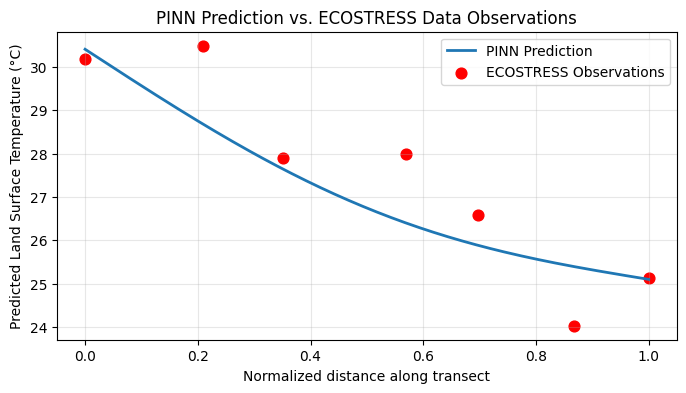

In [30]:
plt.figure(figsize=(8,4))
plt.plot(x_plot, T_base, linewidth=2, label = "PINN Prediction")
plt.xlabel("Normalized distance along transect")
plt.ylabel("Predicted Land Surface Temperature (°C)")
plt.title("PINN Prediction vs. ECOSTRESS Data Observations")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)
plt.scatter(x_obs, y_obs, color="red", s=60, label="ECOSTRESS Observations")
plt.legend()
plt.show()

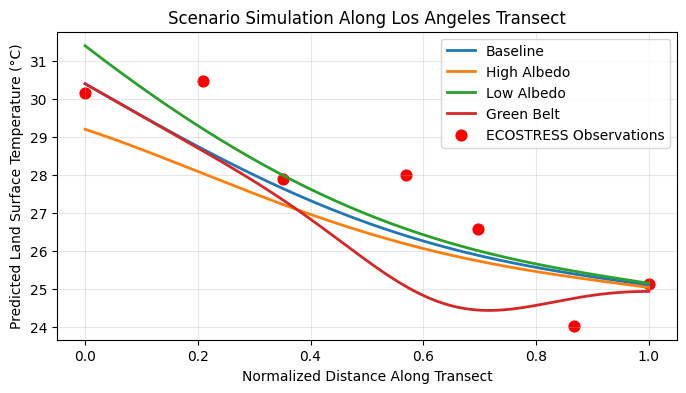

In [28]:
plt.figure(figsize=(8,4))

for scenario_name, temperatures in scenario_predictions.items():
    plt.plot(
      x_plot,
      temperatures,
      linewidth=2,
      label=scenario_name
    )

plt.scatter(
    x_obs,
    y_obs,
    color="red",
    s=60,
    label="ECOSTRESS Observations"
)

plt.xlabel("Normalized Distance Along Transect")
plt.ylabel("Predicted Land Surface Temperature (°C)")
plt.title("Scenario Simulation Along Los Angeles Transect")
plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

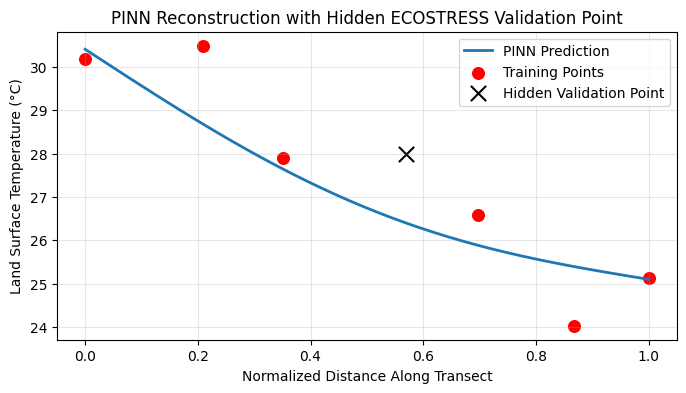

In [29]:
plt.figure(figsize=(8,4))

plt.plot(
    x_plot,
    model.predict(x_plot),
    linewidth=2,
    label="PINN Prediction"
)

plt.scatter(
    x_train,
    y_train,
    color="red",
    s=70,
    label="Training Points"
)

plt.scatter(
    x_test,
    y_test,
    color="black",
    marker="x",
    s=120,
    label="Hidden Validation Point"
)

plt.xlabel("Normalized Distance Along Transect")

plt.ylabel("Land Surface Temperature (°C)")

plt.title("PINN Reconstruction with Hidden ECOSTRESS Validation Point")

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

In [22]:
y_pred = model.predict(x_obs)
mae = np.mean(np.abs(y_pred.flatten()-y_obs.flatten()))
print("Mean Absolute Error (MAE):", mae)

from sklearn.metrics import r2_score
r2 = r2_score(y_obs, y_pred)
print("R^2:", r2)

Mean Absolute Error (MAE): 0.8542129530280752
R^2: 0.763494132925198


0.8542129530280752


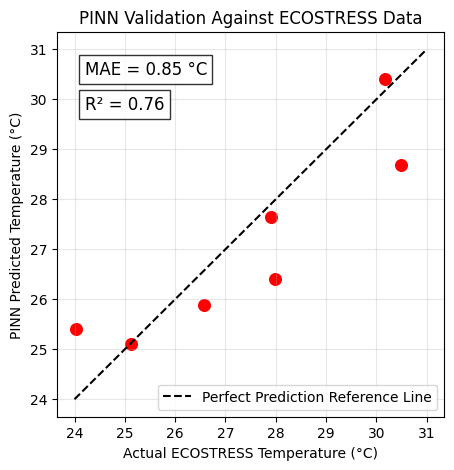

In [23]:
plt.figure(figsize=(5,5))
plt.scatter(y_obs,
            y_pred,
            color="red",
            s=70)
plt.plot([24,31],
           [24,31],
           'k--',
           label="Perfect Prediction Reference Line")
plt.xlabel("Actual ECOSTRESS Temperature (°C)")

plt.ylabel("PINN Predicted Temperature (°C)")

plt.title("PINN Validation Against ECOSTRESS Data")

plt.legend()
mae = np.mean(np.abs(y_pred.flatten() - y_obs.flatten()))
print(mae)
plt.grid(True, alpha=0.3)
plt.text(24.2,30.5,
         f"MAE = {mae:.2f} °C",
         fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8))
plt.text(24.2,29.8,
         f"R² = {r2:.2f}",
         fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8))
plt.show()
